In [1]:
import pandas as pd
dfdirt = pd.read_csv("netflix_top10.csv")
dfdirt.head(10)

,week,category,weekly_rank,show_title,season_title,weekly_hours_viewed,runtime,weekly_views,cumulative_weeks_in_top_10,is_staggered_launch,episode_launch_details
0,2023-08-27,Films (English),1,The Monkey King,NaN,23200000,1.6167,14400000.0,2,False,NaN
1,2023-08-27,Films (English),2,Heart of Stone,NaN,28500000,2.1000,13600000.0,3,False,NaN
2,2023-08-27,Films (English),3,You Are So Not Invited to My Bat Mitzvah,NaN,21300000,1.7333,12300000.0,1,False,NaN
3,2023-08-27,Films (English),4,Street Kings,NaN,10300000,1.8167,5700000.0,2,False,NaN
4,2023-08-27,Films (English),5,The Boss Baby,NaN,9000000,1.6333,5500000.0,10,False,NaN
5,2023-08-27,Films (English),6,Jurassic World: Fallen Kingdom,NaN,10100000,2.1333,4700000.0,1,False,NaN
6,2023-08-27,Films (English),7,The Pope's Exorcist,NaN,6500000,1.7333,3800000.0,2,False,NaN
7,2023-08-27,Films (English),8,Half Brothers,NaN,5900000,1.6000,3700000.0,2,False,NaN
8,2023-08-27,Films (English),9,Madagascar,NaN,4800000,1.4333,3300000.0,1,False,NaN
9,2023-08-27,Films (English),10,Dora and the Lost City of Gold,NaN,4900000,1.7000,2900000.0,2,False,NaN


In [2]:
dfdirt.info()

<class 'pandas.DataFrame'>
RangeIndex: 4520 entries, 0 to 4519
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   week                        4520 non-null   str    
 1   category                    4520 non-null   str    
 2   weekly_rank                 4520 non-null   int64  
 3   show_title                  4520 non-null   str    
 4   season_title                2187 non-null   str    
 5   weekly_hours_viewed         4520 non-null   int64  
 6   runtime                     440 non-null    float64
 7   weekly_views                440 non-null    float64
 8   cumulative_weeks_in_top_10  4520 non-null   int64  
 9   is_staggered_launch         4520 non-null   bool   
 10  episode_launch_details      17 non-null     str    
dtypes: bool(1), float64(2), int64(3), str(5)
memory usage: 357.7 KB


In [5]:
dfdirt['avg_hours_per_view'] = dfdirt['weekly_hours_viewed'] / dfdirt['weekly_views']

dfdirt['week'] = pd.to_datetime(dfdirt['week'])

print(dfdirt[['week', 'show_title', 'avg_hours_per_view']].head())

        week                                show_title  avg_hours_per_view
0 2023-08-27                           The Monkey King            1.611111
1 2023-08-27                            Heart of Stone            2.095588
2 2023-08-27  You Are So Not Invited to My Bat Mitzvah            1.731707
3 2023-08-27                              Street Kings            1.807018
4 2023-08-27                             The Boss Baby            1.636364


In [6]:
dfdirt.groupby(dfdirt["week"].dt.year)

In [7]:
print(dfdirt[['week', 'show_title', 'avg_hours_per_view']].head())

        week                                show_title  avg_hours_per_view
0 2023-08-27                           The Monkey King            1.611111
1 2023-08-27                            Heart of Stone            2.095588
2 2023-08-27  You Are So Not Invited to My Bat Mitzvah            1.731707
3 2023-08-27                              Street Kings            1.807018
4 2023-08-27                             The Boss Baby            1.636364


In [8]:
dfdirt.groupby(dfdirt["week"].dt.year)

In [9]:
dfdirt.groupby("week")["weekly_views"].agg(["mean", "median", "std", "min", "max"])

,mean,median,std,min,max
week,,,,,
2021-07-04,NaN,NaN,NaN,NaN,NaN
2021-07-11,NaN,NaN,NaN,NaN,NaN
2021-07-18,NaN,NaN,NaN,NaN,NaN
2021-07-25,NaN,NaN,NaN,NaN,NaN
2021-08-01,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...
2023-07-30,4442500.0,2950000.0,3.977107e+06,1100000.0,22000000.0
2023-08-06,4675000.0,3150000.0,4.630266e+06,1000000.0,23600000.0
2023-08-13,4222500.0,2950000.0,5.096227e+06,1100000.0,33100000.0


In [12]:
dfdirt[dfdirt["week"].dt.year.isin([2021, 2022, 2023])]

,week,category,weekly_rank,show_title,season_title,weekly_hours_viewed,runtime,weekly_views,cumulative_weeks_in_top_10,is_staggered_launch,episode_launch_details,avg_hours_per_view
0,2023-08-27,Films (English),1,The Monkey King,NaN,23200000,1.6167,14400000.0,2,False,NaN,1.611111
1,2023-08-27,Films (English),2,Heart of Stone,NaN,28500000,2.1000,13600000.0,3,False,NaN,2.095588
2,2023-08-27,Films (English),3,You Are So Not Invited to My Bat Mitzvah,NaN,21300000,1.7333,12300000.0,1,False,NaN,1.731707
3,2023-08-27,Films (English),4,Street Kings,NaN,10300000,1.8167,5700000.0,2,False,NaN,1.807018
4,2023-08-27,Films (English),5,The Boss Baby,NaN,9000000,1.6333,5500000.0,10,False,NaN,1.636364
...,...,...,...,...,...,...,...,...,...,...,...,...
4515,2021-07-04,TV (Non-English),6,Elite,Elite: Season 1,10530000,NaN,NaN,1,False,NaN,NaN
4516,2021-07-04,TV (Non-English),7,Elite,Elite: Season 3,10200000,NaN,NaN,1,False,NaN,NaN
4517,2021-07-04,TV (Non-English),8,Elite,Elite: Season 2,10140000,NaN,NaN,1,False,NaN,NaN
4518,2021-07-04,TV (Non-English),9,Katla,Katla: Season 1,9190000,NaN,NaN,1,False,NaN,NaN


In [13]:
dfdirt.groupby([dfdirt["week"].dt.year, "category"])["weekly_views"].sum()

week  category           
2021  Films (English)                0.0
      Films (Non-English)            0.0
      TV (English)                   0.0
      TV (Non-English)               0.0
2022  Films (English)                0.0
      Films (Non-English)            0.0
      TV (English)                   0.0
      TV (Non-English)               0.0
2023  Films (English)        815700000.0
      Films (Non-English)    365100000.0
      TV (English)           445200000.0
      TV (Non-English)       288200000.0
Name: weekly_views, dtype: float64

In [14]:
dfdirt.groupby([dfdirt["week"].dt.year, "category"])["weekly_hours_viewed"].sum()

week  category           
2021  Films (English)         4316040000
      Films (Non-English)     1437160000
      TV (English)            7696060000
      TV (Non-English)        6839830000
2022  Films (English)         8679580000
      Films (Non-English)     3632790000
      TV (English)           20159900000
      TV (Non-English)        9946540000
2023  Films (English)         4592100000
      Films (Non-English)     2295210000
      TV (English)           10456270000
      TV (Non-English)        6826340000
Name: weekly_hours_viewed, dtype: int64

In [15]:
dfdirt.groupby([dfdirt["week"].dt.year, "category"])["weekly_hours_viewed"].quantile([0.25, 0.5, 0.75])

week  category                 
2021  Films (English)      0.25     7512500.0
                           0.50    10670000.0
                           0.75    17080000.0
      Films (Non-English)  0.25     2135000.0
                           0.50     3325000.0
                           0.75     7122500.0
      TV (English)         0.25    13915000.0
                           0.50    19160000.0
                           0.75    32100000.0
      TV (Non-English)     0.25     9720000.0
                           0.50    13020000.0
                           0.75    19802500.0
2022  Films (English)      0.25     7360000.0
                           0.50    10375000.0
                           0.75    18925000.0
      Films (Non-English)  0.25     2677500.0
                           0.50     4120000.0
                           0.75     8280000.0
      TV (English)         0.25    15982500.0
                           0.50    24265000.0
                           0.75    41817500.0
  

In [16]:
dfdirt.groupby("category")["weekly_hours_viewed"].quantile([0.25, 0.5, 0.75])

category                 
Films (English)      0.25     6702500.0
                     0.50     9560000.0
                     0.75    16925000.0
Films (Non-English)  0.25     2520000.0
                     0.50     3960000.0
                     0.75     7940000.0
TV (English)         0.25    14792500.0
                     0.50    21325000.0
                     0.75    37890000.0
TV (Non-English)     0.25     9792500.0
                     0.50    13385000.0
                     0.75    21557500.0
Name: weekly_hours_viewed, dtype: float64

In [17]:
quantiles = dfdirt.groupby(
    [dfdirt["week"].dt.year, "category"]
)["weekly_hours_viewed"].quantile([0.25, 0.5, 0.75]).unstack()

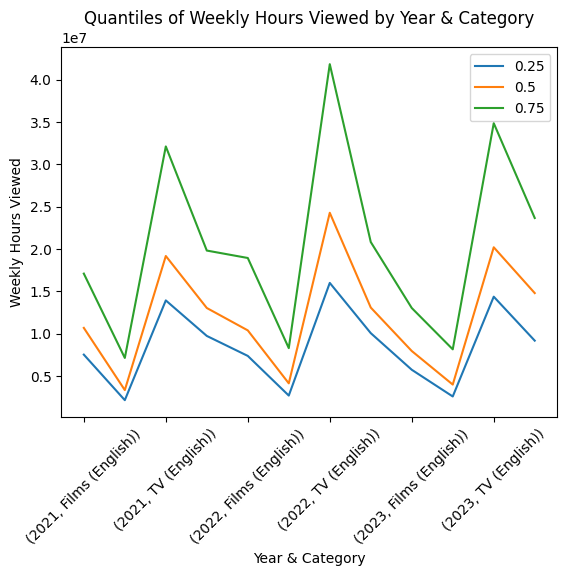

In [18]:
import matplotlib.pyplot as plt

quantiles.plot()

plt.title("Quantiles of Weekly Hours Viewed by Year & Category")
plt.xlabel("Year & Category")
plt.ylabel("Weekly Hours Viewed")
plt.xticks(rotation=45)

plt.show()

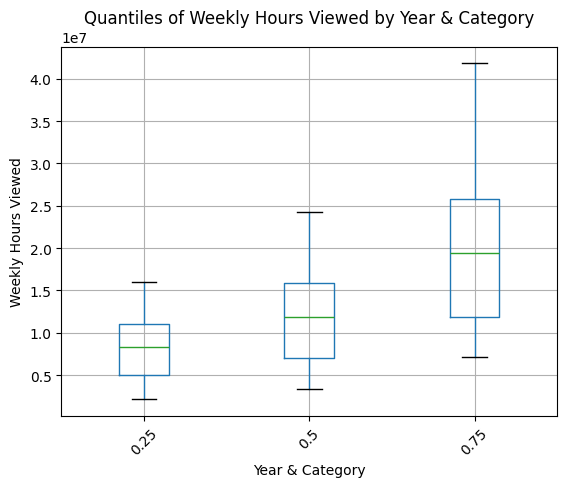

In [19]:
quantiles.boxplot()

plt.title("Quantiles of Weekly Hours Viewed by Year & Category")
plt.xlabel("Year & Category")
plt.ylabel("Weekly Hours Viewed")
plt.xticks(rotation=45)

plt.show()

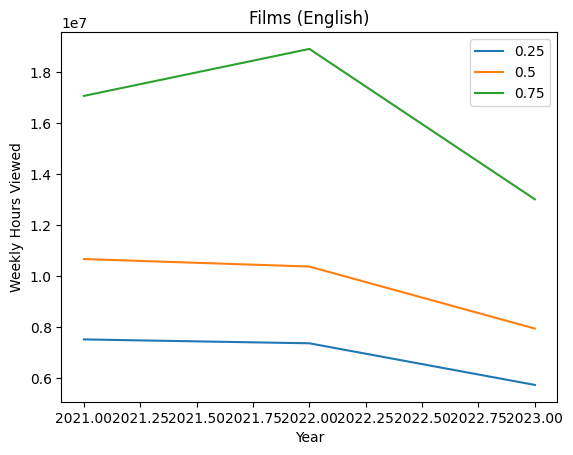

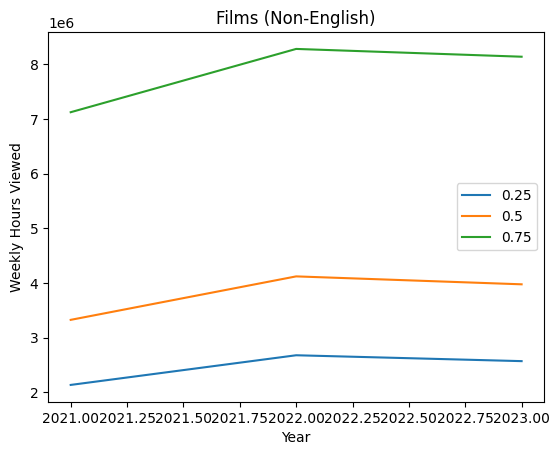

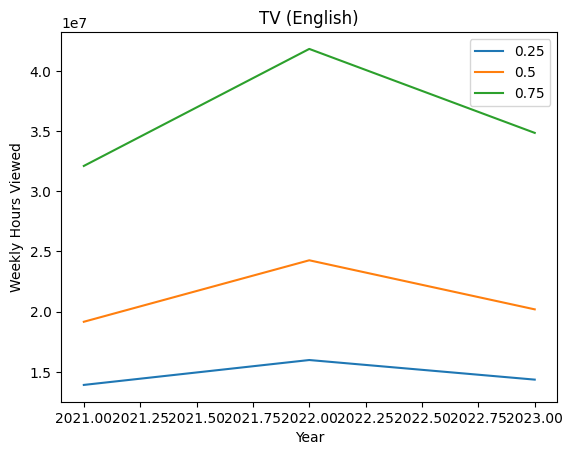

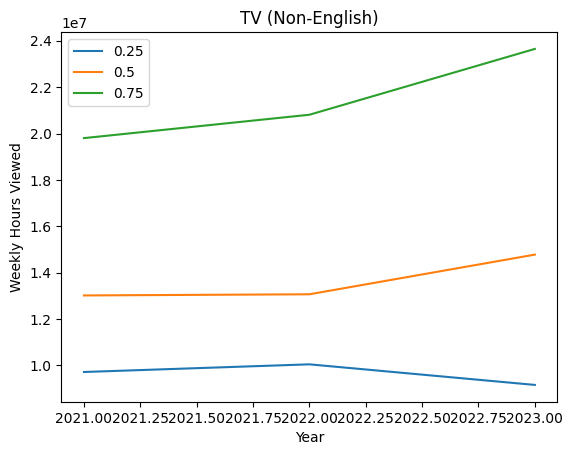

In [20]:
for category in quantiles.index.get_level_values(1).unique():
    quantiles.xs(category, level=1).plot(title=category)
    plt.xlabel("Year")
    plt.ylabel("Weekly Hours Viewed")
    plt.show()

In [4]:
import pandas as pd

In [7]:
dfdirt = pd.read_csv("netflix_top10.csv")
dfdirt.info()

<class 'pandas.DataFrame'>
RangeIndex: 4520 entries, 0 to 4519
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   week                        4520 non-null   str    
 1   category                    4520 non-null   str    
 2   weekly_rank                 4520 non-null   int64  
 3   show_title                  4520 non-null   str    
 4   season_title                2187 non-null   str    
 5   weekly_hours_viewed         4520 non-null   int64  
 6   runtime                     440 non-null    float64
 7   weekly_views                440 non-null    float64
 8   cumulative_weeks_in_top_10  4520 non-null   int64  
 9   is_staggered_launch         4520 non-null   bool   
 10  episode_launch_details      17 non-null     str    
dtypes: bool(1), float64(2), int64(3), str(5)
memory usage: 357.7 KB


In [10]:
dfdirt['week'] = pd.to_datetime(dfdirt['week'])

In [11]:
dfdirt.groupby(dfdirt["week"].dt.year)

In [12]:
import matplotlib.pyplot as plt

In [13]:
distrib_year = dfdirt.groupby([dfdirt["week"].dt.year, "category"])["weekly_hours_viewed"].agg(["mean", "median", "std", "min", "max"])

In [14]:
print(distrib_year)

                                  mean      median           std      min  \
week category                                                               
2021 Films (English)      1.660015e+07  10670000.0  1.822458e+07  3430000   
     Films (Non-English)  5.527538e+06   3325000.0  5.823840e+06   930000   
     TV (English)         2.960023e+07  19160000.0  2.857966e+07  8750000   
     TV (Non-English)     2.630704e+07  13020000.0  5.697276e+07  6060000   
2022 Films (English)      1.669150e+07  10375000.0  1.677370e+07  3940000   
     Films (Non-English)  6.986135e+06   4120000.0  7.502492e+06  1180000   
     TV (English)         3.876904e+07  24265000.0  4.626455e+07  8310000   
     TV (Non-English)     1.912796e+07  13070000.0  1.822122e+07  5400000   
2023 Films (English)      1.312029e+07   7940000.0  1.557603e+07  3200000   
     Films (Non-English)  6.557743e+06   3975000.0  6.734114e+06  1210000   
     TV (English)         2.987506e+07  20190000.0  2.878933e+07  1500000   

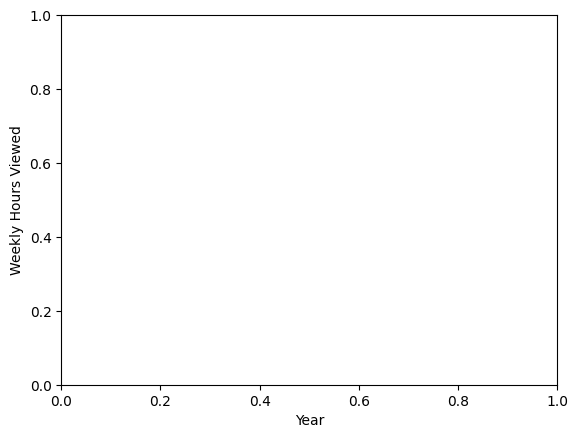

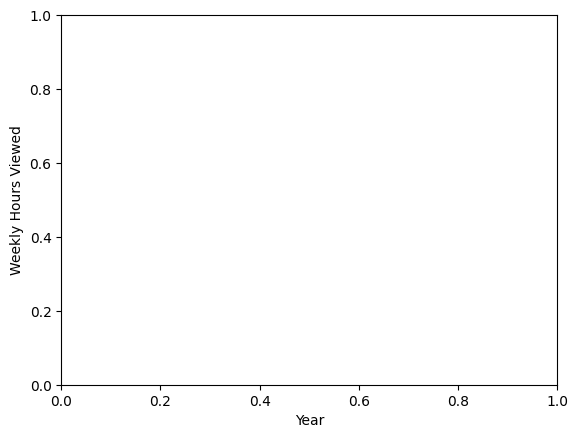

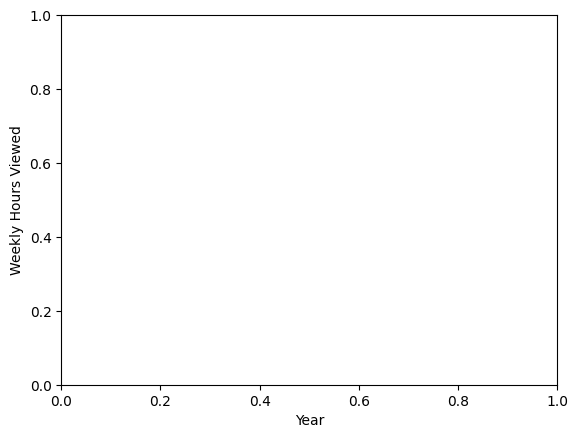

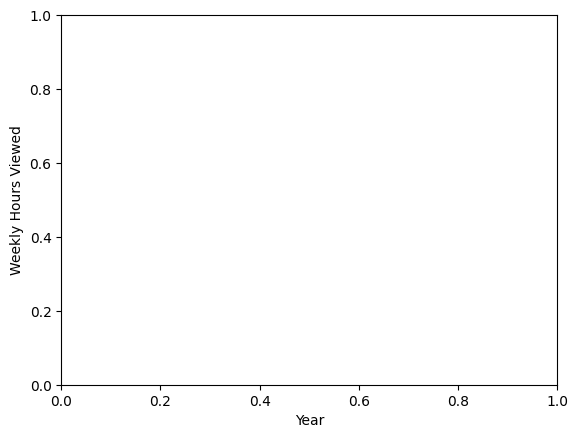

In [16]:
for category in distrib_year.index.get_level_values(1).unique():
    distrib_year.xs(category, level=1).boxplot
    plt.xlabel("Year")
    plt.ylabel("Weekly Hours Viewed")
    plt.show()

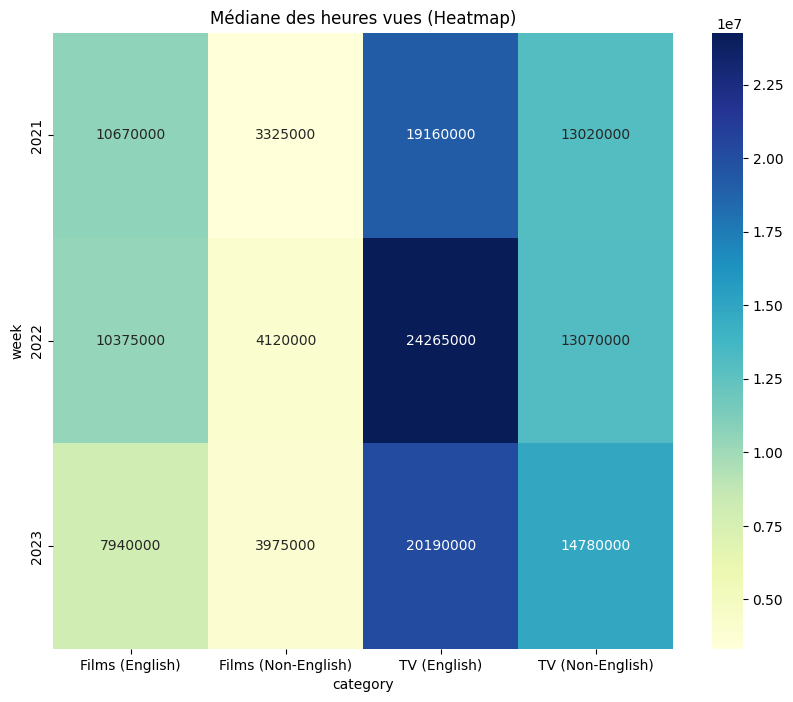

In [19]:
# On pivote les données pour avoir les années en lignes et catégories en colonnes
pivot_table = data_plot.pivot(index='week', columns='category', values='median')

plt.figure(figsize=(10, 8))
sns.heatmap(pivot_table, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Médiane des heures vues (Heatmap)")
plt.show()

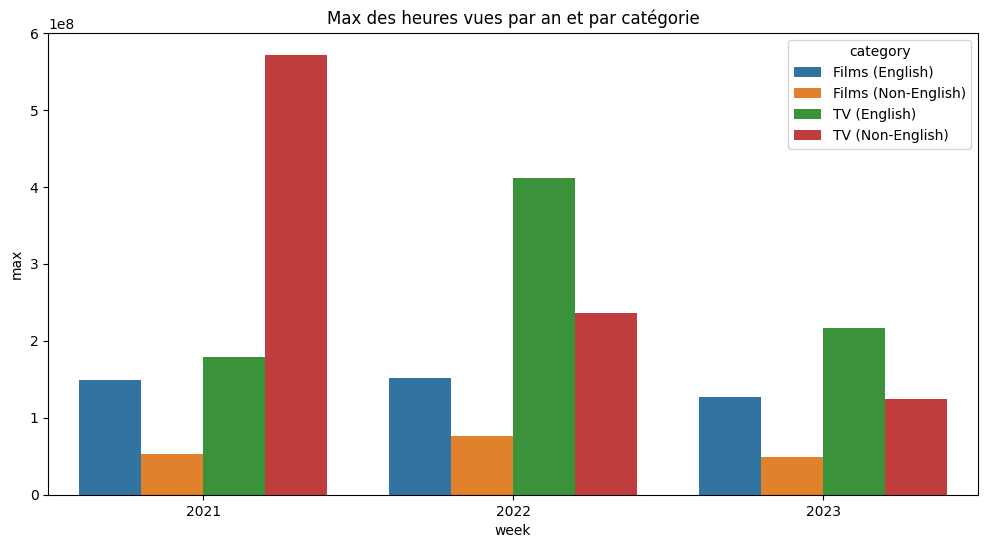

In [20]:
plt.figure(figsize=(12, 6))
sns.barplot(data=data_plot, x='week', y='max', hue='category')
plt.title("Max des heures vues par an et par catégorie")
plt.show()

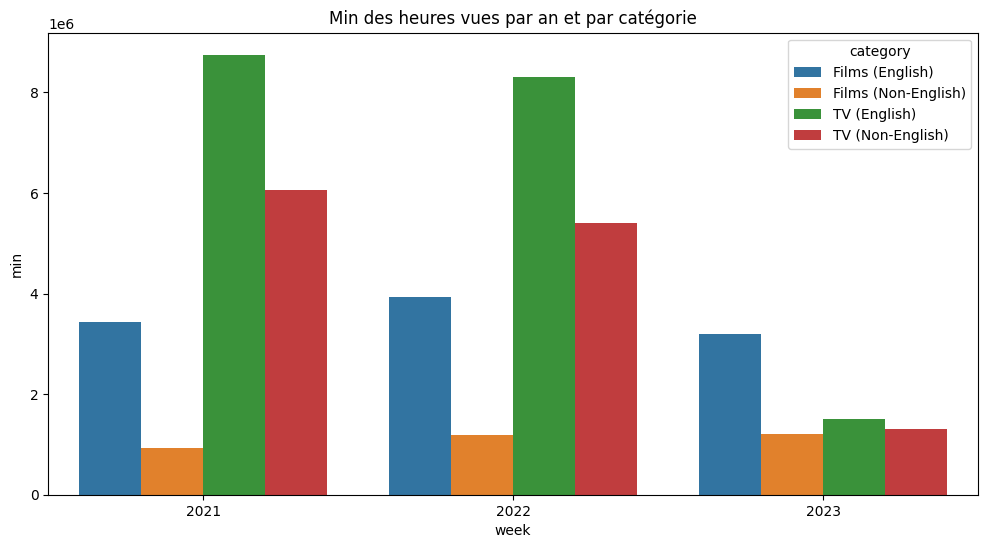

In [22]:
plt.figure(figsize=(12, 6))
sns.barplot(data=data_plot, x='week', y='min', hue='category')
plt.title("Min des heures vues par an et par catégorie")
plt.show()

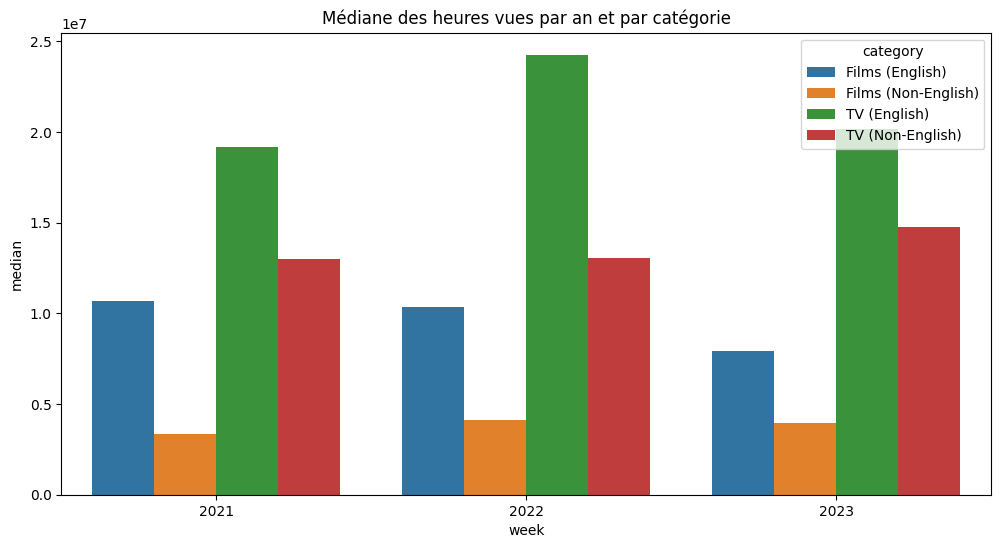

In [21]:
plt.figure(figsize=(12, 6))
sns.barplot(data=data_plot, x='week', y='median', hue='category')
plt.title("Médiane des heures vues par an et par catégorie")
plt.show()

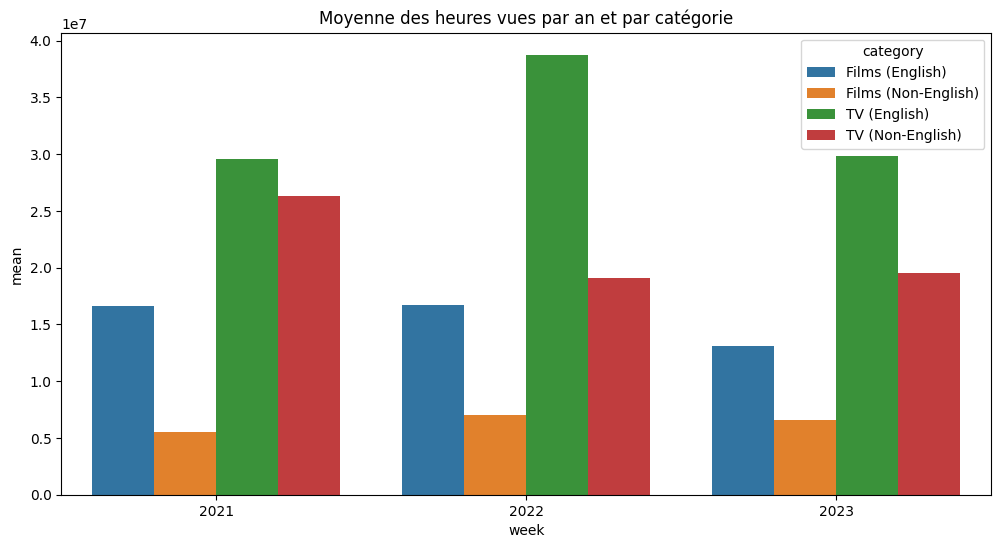

In [17]:
import seaborn as sns

# On reset l'index pour que 'week' (année) et 'category' deviennent des colonnes utilisables
data_plot = distrib_year.reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=data_plot, x='week', y='mean', hue='category')
plt.title("Moyenne des heures vues par an et par catégorie")
plt.show()

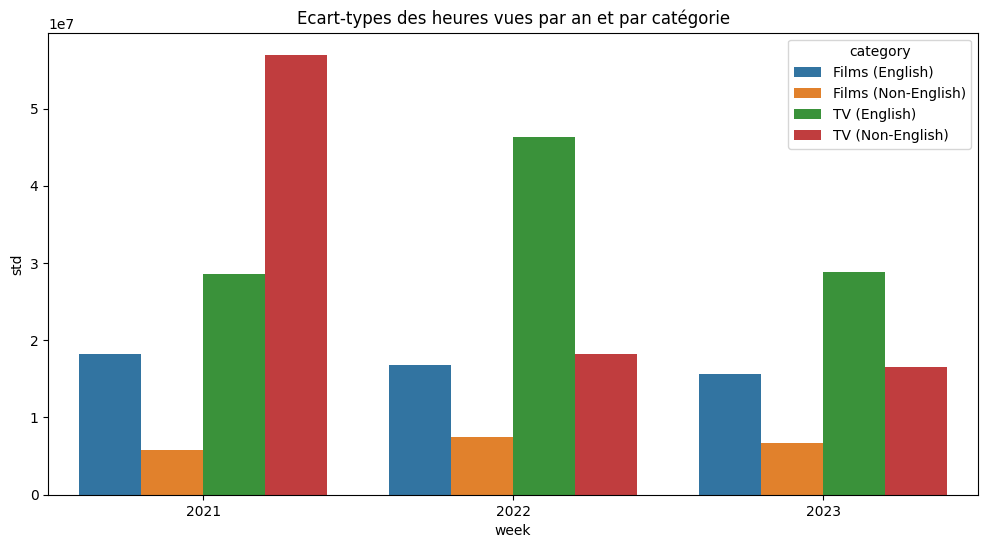

In [7]:
plt.figure(figsize=(12, 6))
sns.barplot(data=data_plot, x='week', y='std', hue='category')
plt.title("Ecart-types des heures vues par an et par catégorie")
plt.savefig("Ecart-types des heures vues par an et par cat)", dpi=300, bbox_inches='tight')
plt.show()

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
dfdirt = pd.read_csv("netflix_top10.csv")

In [6]:
dfdirt['week'] = pd.to_datetime(dfdirt['week'])
dfdirt.groupby(dfdirt["week"].dt.year)
distrib_year = dfdirt.groupby([dfdirt["week"].dt.year, "category"])["weekly_hours_viewed"].agg(["mean", "median", "std", "min", "max"])
data_plot = distrib_year.reset_index()
pivot_table = data_plot.pivot(index='week', columns='category', values='median')
data_plot = distrib_year.reset_index()

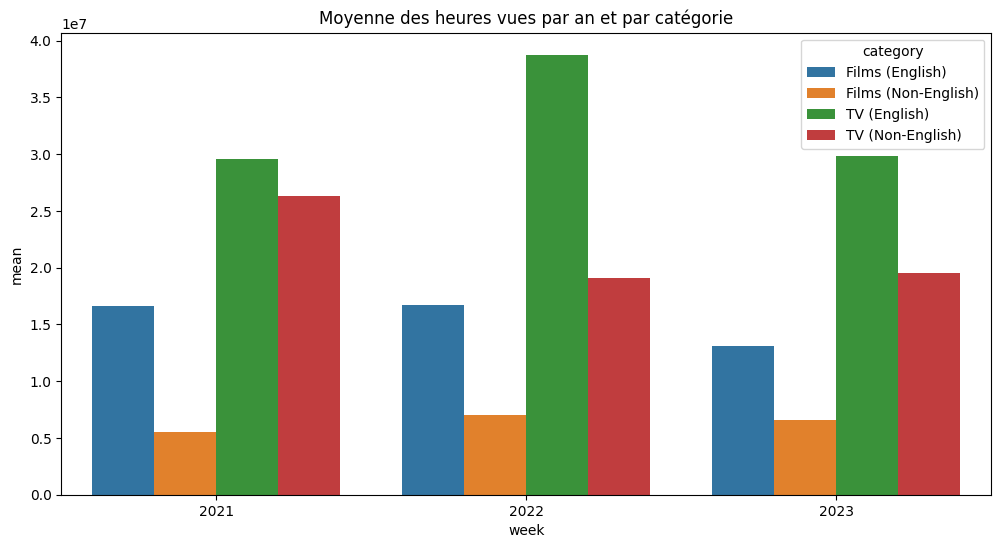

In [9]:
plt.figure(figsize=(12, 6))
sns.barplot(data=data_plot, x='week', y='mean', hue='category')
plt.title("Moyenne des heures vues par an et par catégorie")
plt.savefig("Moyenne des heures vues par an et par cat)", dpi=300, bbox_inches='tight')
plt.show()

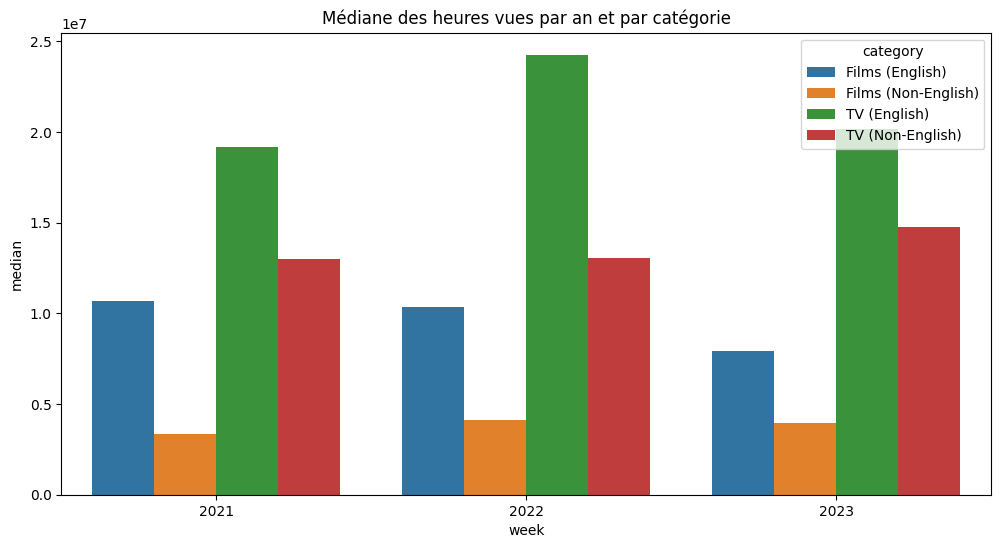

In [11]:
plt.figure(figsize=(12, 6))
sns.barplot(data=data_plot, x='week', y='median', hue='category')
plt.title("Médiane des heures vues par an et par catégorie")
plt.savefig("Médiane des heures vues par an et par cat)", dpi=300, bbox_inches='tight')
plt.show()

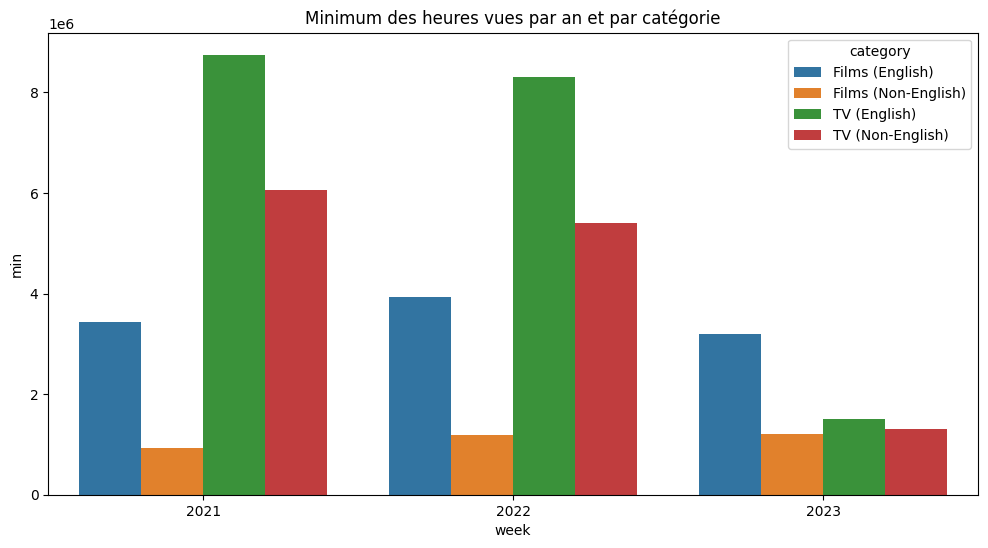

In [12]:
plt.figure(figsize=(12, 6))
sns.barplot(data=data_plot, x='week', y='min', hue='category')
plt.title("Minimum des heures vues par an et par catégorie")
plt.savefig("Min des heures vues par an et par cat)", dpi=300, bbox_inches='tight')
plt.show()

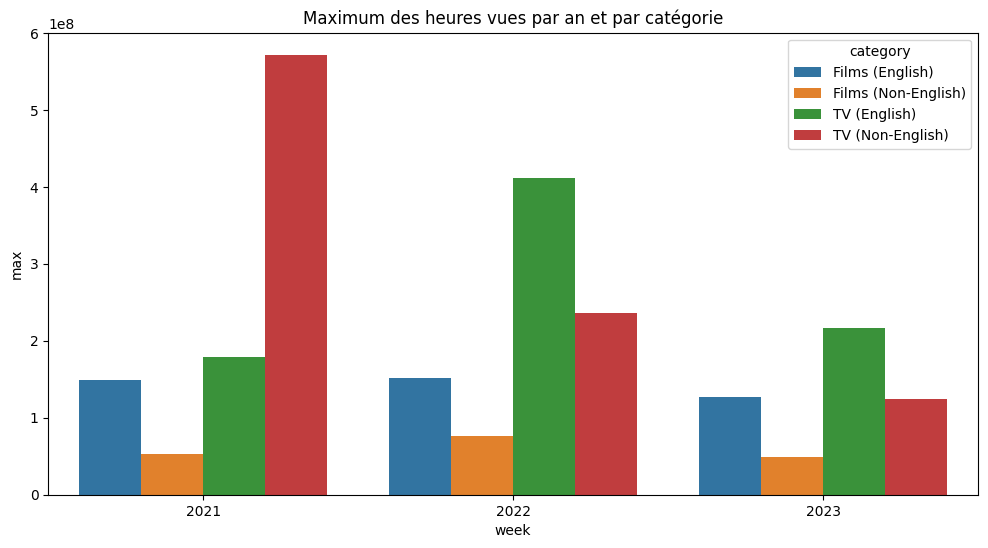

In [13]:
plt.figure(figsize=(12, 6))
sns.barplot(data=data_plot, x='week', y='max', hue='category')
plt.title("Maximum des heures vues par an et par catégorie")
plt.savefig("Max des heures vues par an et par cat)", dpi=300, bbox_inches='tight')

plt.show()

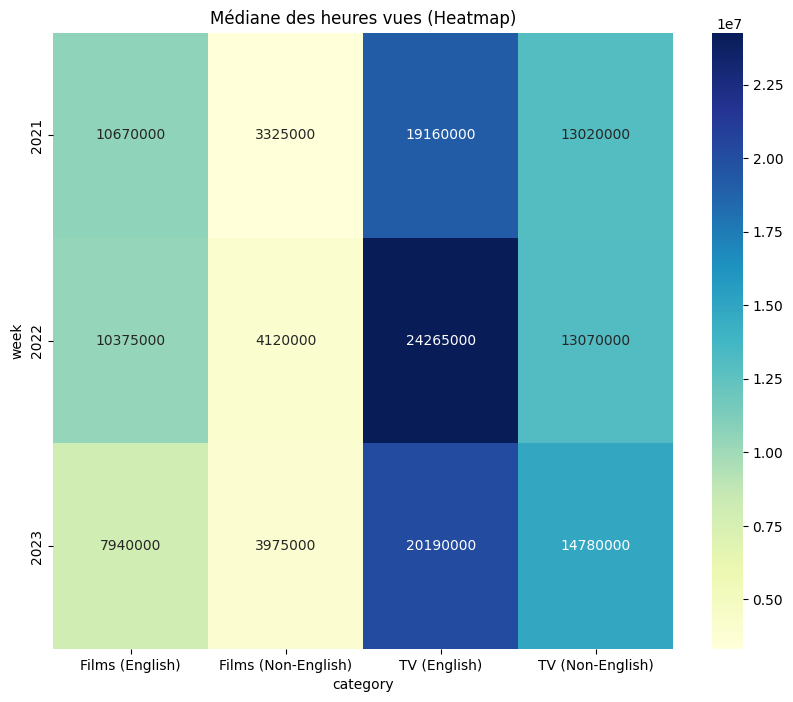

In [14]:
plt.figure(figsize=(10, 8))
sns.heatmap(pivot_table, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Médiane des heures vues (Heatmap)")
plt.savefig("Heatmap Médiane des heures vues)", dpi=300, bbox_inches='tight')
plt.show()